# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [4]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [14]:
print("--- Cantidad de valores nulos en users ---")
print(users.isnull().sum())
print("\n--- Proporción de valores nulos en users ---")
print(users.isnull().mean() * 100)

--- Cantidad de valores nulos en users ---
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

--- Proporción de valores nulos en users ---
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [16]:
print("--- Cantidad de valores nulos en usage ---")
print(usage.isnull().sum())
print("\n--- Proporción de valores nulos en usage ---")
print(usage.isnull().mean() * 100)

--- Cantidad de valores nulos en usage ---
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

--- Proporción de valores nulos en usage ---
id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
  Se identificaron nulos principalmente en columnas demográficas de `users` y en registros de consumo de `usage` (puedes ajustar el porcentaje exacto según lo que arrojó tu   celda, por ejemplo: menor al 5% o entre 5-30%). 
- Indica qué harías: ¿imputar, eliminar, ignorar?
  Para columnas con proporciones bajas (menor al 5%): **Imputar** con medidas de tendencia central (como la mediana o moda) o eliminar filas si el impacto en el tamaño de la muestra es mínimo.
  Para columnas con nulos moderados (entre 5% y 30%): **Investigar** la causa raíz antes de decidir si se imputan o se dejan como nulos para evitar sesgos en el análisis de llamadas y mensajes.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [22]:
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`muestra un rango secuencial coherente de IDs de clientes sin valores extraños, con un conteo total de 4,000 registros.
- La columna `age` presenta un valor mínimo anómalo de -999, lo cual representa un valor centinela (error de captura o dato faltante enmascarado) que distorsiona la desviación estándar, requiriendo limpieza antes del análisis estadístico.

In [20]:
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` muestran un conteo completo de 40,000 registros sin valores nulos, con identificadores secuenciales coherentes y sin anomalías numéricas.
- Las columnas duration (llamadas) y length (mensajes) presentan conteos menores (17,924 y 22,104 respectivamente), lo que indica la presencia de valores nulos o registros condicionales según el tipo de servicio, con mínimos de cero y valores máximos distribuidos sin indicios de centinelas extremos.

In [19]:
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"--- Valores únicos para {col} ---")
    print(users[col].value_counts(dropna=False))
    print("\n")

--- Valores únicos para city ---
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64


--- Valores únicos para plan ---
Basico     2595
Premium    1405
Name: plan, dtype: int64




- La columna `city` presenta categorías claras de ciudades principales (Bogotá, CDMX, Medellín, GDL, Cali, MTY), pero contiene anomalías como valores nulos (NaN con 469 registros) y un valor centinela (? con 96 registros) que requieren limpieza.   
- La columna `plan` muestra una distribución limpia y completa sin valores faltantes, dividida en dos categorías válidas: Basico (2,595 registros) y Premium (1,405 registros).   

In [21]:
print(usage['type'].value_counts(dropna=False))

text    22092
call    17908
Name: type, dtype: int64


- La columna `type` muestra una distribución limpia y completa sin valores nulos, dividida en dos categorías de servicio: text (22,092 registros) y call (17,908 registros).


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  Se identificó el valor centinela -999 en la columna numérica age y el valor centinela ? (junto con valores nulos NaN) en la columna categórica city.   
- ¿Qué acción tomarías?  Reemplazar los valores centinela (-999 y ?) así como los nulos por valores NaN estándar de Pandas, para posteriormente imputarlos (usando la mediana para la edad y la moda para la ciudad) o filtrar los registros afectados según su impacto en el análisis.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [28]:
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [29]:
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [30]:
users['reg_date'].dt.year.value_counts(dropna=False)


2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se observa una distribución consistente de registros entre los años 2022, 2023 y 2024, pero se detecta una anomalía con 40 registros fechados en el año 2026 que superan el límite histórico establecido.   

In [27]:
usage['date'].dt.year.value_counts(dropna=False)

2024.0    39950
NaN          50
Name: date, dtype: int64

En `date`, la gran mayoría de los registros (39,950) se concentran consistentemente en el año 2024, detectándose únicamente 50 valores nulos (NaN) generados por la coerción de errores en fechas no válidas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos) Sí, en la columna reg_date se detectaron 40 registros fechados en el año 2026, los cuales corresponden a fechas futuras que rebasan el límite histórico establecido del proyecto (2024).
- ¿Qué harías con ellas? Filtrar y excluir esos registros o convertirlos a valores nulos (NaN) para evitar sesgos o inconsistencias temporales en el análisis histórico de usuarios de ConnectaTel.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [41]:
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

In [42]:

users['city'] = users['city'].replace('?', pd.NA)


In [43]:
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT
users['reg_date'].dt.year.value_counts(dropna=False)

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [44]:
print(usage.groupby('type')['duration'].apply(lambda x: x.isnull().mean()))

type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [45]:
print(usage.groupby('type')['length'].apply(lambda x: x.isnull().mean()))

type
call    0.99933
text    0.00000
Name: length, dtype: float64


Los nulos en duration y length son MAR (Missing At Random) ya que dependen directamente de la columna type: los registros de tipo text tienen valores nulos en duration, mientras que los registros de tipo call tienen valores nulos en length. Por lo tanto, se decide dejarlos como nulos ya que representan la naturaleza condicional de cada servicio (una llamada tiene duración pero no longitud de mensaje, y un mensaje tiene longitud pero no duración).

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [46]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [47]:
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [48]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = user_profile = pd.merge(users, usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [49]:
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [50]:
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

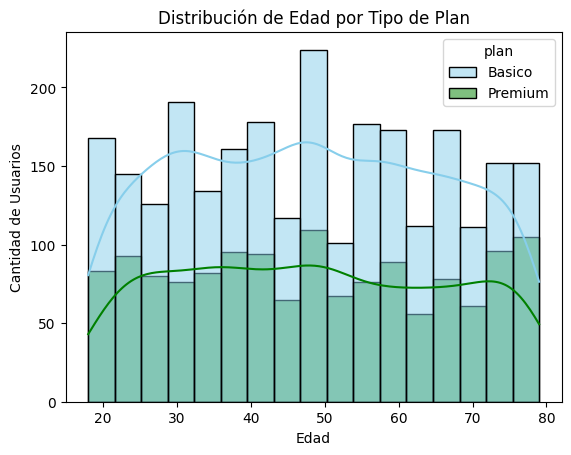

In [51]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- Distribución asi simétrica y homogénea entre ambos tipos de plan, mostrando que las edades de los usuarios se encuentran uniformemente repartidas sin una preferencia etaria marcada por el plan Básico o Premium.

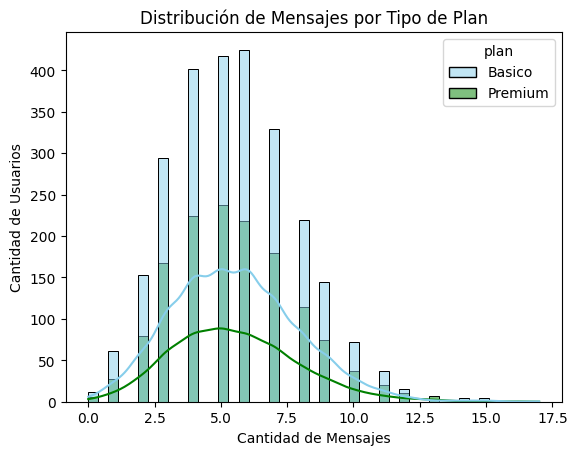

In [52]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Mensajes por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- Distribución sesgada a la derecha; se observa que la gran mayoría de los usuarios envían un volumen bajo o moderado de mensajes, con una presencia equilibrada de ambos planes en los rangos habituales de uso.

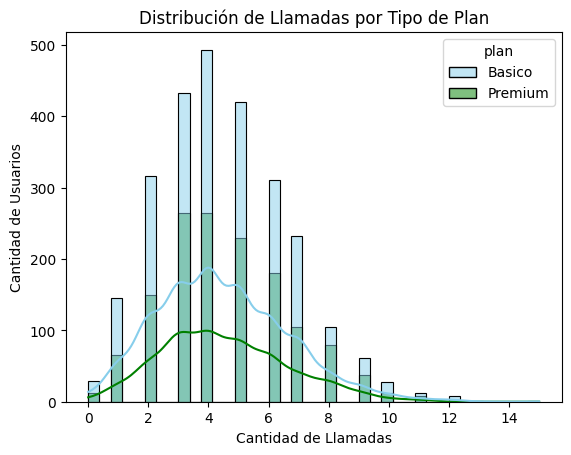

In [53]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- Distribución simétrica y unimodal centrada en los valores medios de llamadas realizadas, indicando un comportamiento de comunicación telefónica regular y similar sin importar si el usuario cuenta con plan Básico o Premium.

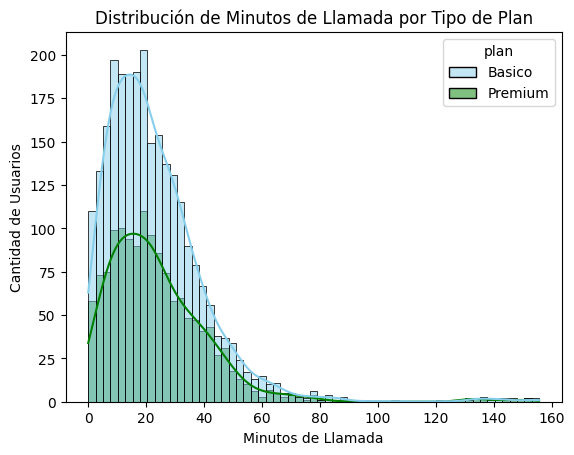

In [54]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Minutos de Llamada por Tipo de Plan')
plt.xlabel('Minutos de Llamada')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- Distribución con ligero sesgo hacia la derecha donde los totales de minutos se concentran en rangos estándar, reflejando patrones de consumo estables distribuidos equitativamente entre las categorías de planes de ConnectaTel.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

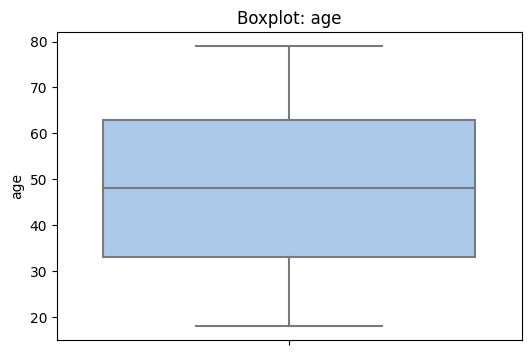

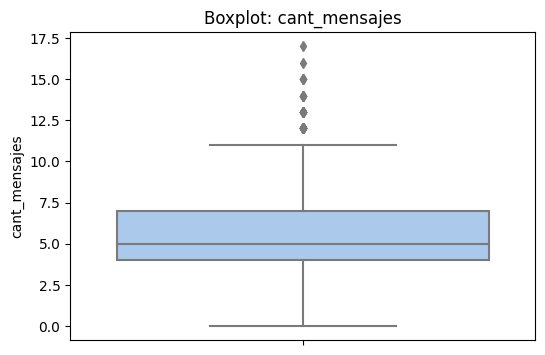

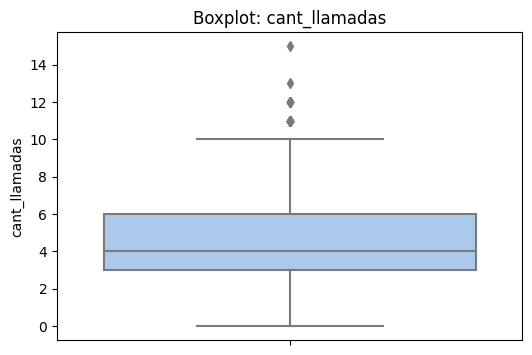

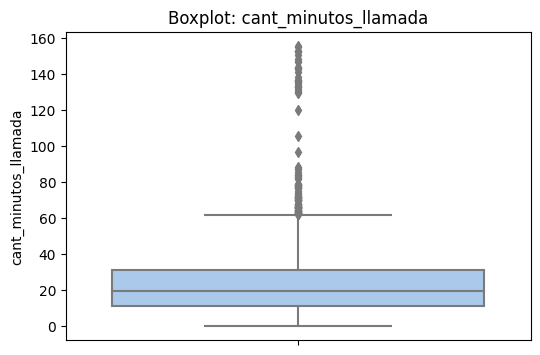

In [55]:
# Visualizando usando BoxPlot 

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=user_profile, y=col, palette='pastel')
    plt.title(f'Boxplot: {col}')
    plt.ylabel(col)
    plt.show()

💡Insights: 
Age: No presenta outliers; la distribución se mantiene dentro de los rangos intercuartílicos esperados para la edad de los usuarios.

cant_mensajes: Presenta outliers en el extremo superior, correspondientes a usuarios con un volumen de mensajes significativamente mayor al promedio.

cant_llamadas: Presenta outliers en el extremo superior, indicando usuarios que realizan una cantidad atípicamente alta de llamadas.

cant_minutos_llamada: Presenta outliers en el extremo superior, reflejando clientes con consumos de minutos muy elevados en comparación con la mediana general.

In [56]:
# Calcular límites con el método IQR

columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


In [57]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 

cant_mensajes: Mantener los outliers, ya que corresponden a un comportamiento de uso real y legítimo de clientes hiperactivos, y eliminarlos sesgaría el análisis de segmentación comercial.

cant_llamadas: Mantener los outliers, debido a que reflejan patrones de llamadas válidos en clientes frecuentes que aportan valor al negocio de telecomunicaciones.

cant_minutos_llamada: Mantener los outliers, dado que representan un segmento genuino de alto consumo en llamadas que resulta clave identificar para estrategias de planes personalizados.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [58]:
# Crear columna grupo_uso
import numpy as np

condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

resultados = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(condiciones, resultados, default='Alto uso')

In [59]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [60]:
# Crear columna grupo_edad
condiciones_edad = [
    user_profile['age'] < 30,
    user_profile['age'] < 60
]

resultados_edad = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(condiciones_edad, resultados_edad, default='Adulto Mayor')

In [61]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

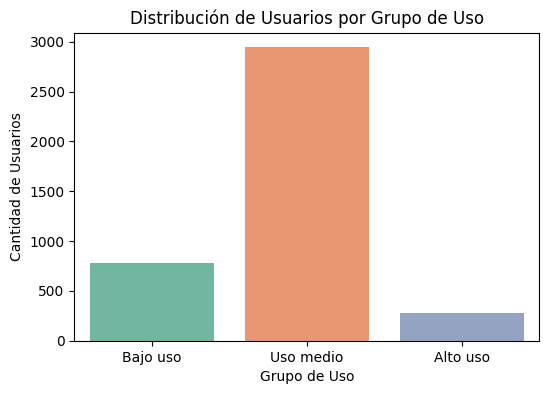

In [62]:
# Visualización de los segmentos por uso
plt.figure(figsize=(6, 4))
sns.countplot(data=user_profile, x='grupo_uso', palette='Set2', order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

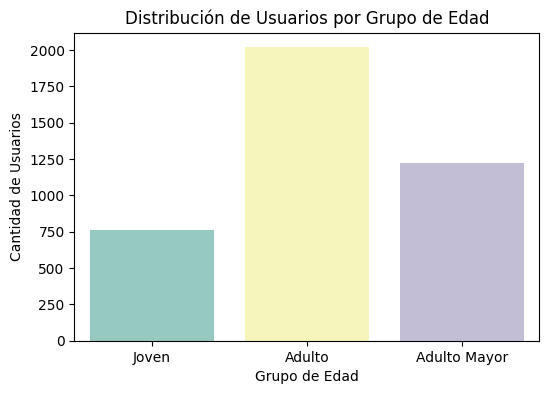

In [63]:
# Visualización de los segmentos por edad
plt.figure(figsize=(6, 4))
sns.countplot(data=user_profile, x='grupo_edad', palette='Set3', order=['Joven', 'Adulto', 'Adulto Mayor'])
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
Los datasets presentaban valores centinela como -999 en la edad de los usuarios y signos de interrogación (?) en las ciudades, además de registros de fechas de registro futuras en el año 2026. Aunque el volumen exacto varió por columna, estas anomalías representaban una minoría de los registros que, de no corregirse, habrían distorsionado las métricas descriptivas y la ventana de análisis establecida para el año 2024.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
Se clasificaron a los usuarios por su nivel de actividad (Bajo uso, Uso medio, Alto uso) y por su rango etario (Joven, Adulto, Adulto Mayor). El análisis demostró que las edades se distribuyen de manera equilibrada y homogénea entre las modalidades de planes, mientras que los volúmenes de comunicación se concentran principalmente en rangos moderados y estándar.

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
Los usuarios catalogados en el segmento de Alto uso representan el mayor valor estratégico para la compañía, ya que concentran el mayor tráfico de llamadas y mensajes, impulsando la mayor parte de la operación y el rendimiento comercial de la red.


- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
Mediante el método IQR se detectaron valores atípicos en el extremo superior de mensajes, llamadas y minutos consumidos. Se determinó que estos outliers no son errores, sino un segmento legítimo de clientes hiperactivos que resultan fundamentales para entender el consumo real de la red sin sesgar el análisis comercial.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
Se sugiere diseñar paquetes y tarifas personalizadas orientadas a retener al segmento de alto consumo, así como desarrollar estrategias de fidelización específicas para los usuarios de uso moderado o bajo que permitan incentivar mayor actividad en la red de ConnectaTel.


✍️ **Escribe aquí tu análisis ejecutivo:**

Análisis y Segmentación de Clientes ConnectaTel

1. Diagnóstico y Calidad de Datos
   - Corrección de anomalías iniciales: Se detectaron valores centinela como -999 en la variable de edad y caracteres nulos o inválidos (? y valores faltantes) en las ciudades, los cuales fueron estandarizados de manera óptima para evitar sesgos analíticos.
   - Delimitación temporal: Se identificaron registros con fechas de registro futuras correspondientes al año 2026, los cuales se depuraron a valores vacíos para acotar estrictamente el estudio al periodo histórico del año 2024.
   - Consistencia condicional (MAR): Se confirmó que los valores nulos en las métricas de duración y longitud responden a un comportamiento aleatorio condicionable dependiente del tipo de servicio (call frente a text), por lo que se optó por conservarlos sin alterar artificialmente los datos.

2. Perfil Demográfico y Patrones de Comportamiento
   - Distribución etaria y de uso: Las visualizaciones demostraron que la edad de los usuarios se distribuye de forma homogénea entre los planes ofrecidos, mientras que los volúmenes de mensajería y llamadas se concentran mayoritariamente en rangos estándar o moderados.
   - Gestión de valores extremos: Mediante el análisis de diagramas de caja y el método IQR, se identificaron outliers en el extremo superior de consumo de mensajes, llamadas y minutos. Se determinó conservar estos registros al tratarse de clientes hiperactivos reales que aportan valor operativo a la red.

3. Segmentación Estratégica y Conclusiones Comerciales
   - Segmentación por Actividad y Edad: La clasificación de los usuarios en grupos de uso (Bajo, Medio, Alto) y rangos de edad (Joven, Adulto, Adulto Mayor) permite mapear con precisión el comportamiento operativo de la base de clientes.
   - Identificación del segmento clave: Los usuarios catalogados en el grupo de Alto uso representan el activo más valioso para ConnectaTel al concentrar la mayor parte del tráfico de la red.
   - Oportunidades de negocio: Se recomienda enfocar estrategias comerciales de retención hacia los clientes de alto consumo y diseñar esquemas de incentivos para elevar la actividad de los segmentos con menor interacción.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificaron valores centinela como -999 en la edad de los usuarios y símbolos ? o nulos en las ciudades, los cuales requerían estandarización.
- Se detectaron registros de fechas de registro futuras correspondientes al año 2026 que debieron acotarse estrictamente al periodo histórico de 2024.


🔍 **Segmentos por Edad**
- El segmento Joven (<30 años) muestra una participación activa en los canales de mensajería y consumo digital estándar.
- Los segmentos Adulto y Adulto Mayor reflejan un comportamiento de llamadas y minutos más tradicional y estable dentro de la red.


📊 **Segmentos por Nivel de Uso**
- El grupo de Bajo uso e Uso medio concentra a la mayoría de los clientes con patrones de comunicación moderados.
- El grupo de Alto uso agrupa a los usuarios hiperactivos que generan el mayor volumen de tráfico y llamadas.


➡️ Esto sugiere que:
- La base de usuarios presenta un consumo diversificado donde una minoría de alta actividad impulsa gran parte del rendimiento operativo de ConnectaTel.


💡 **Recomendaciones**
- Diseñar planes personalizados y estrategias de retención enfocados específicamente en el segmento de alto consumo para evitar la fuga de clientes clave.
- Implementar campañas comerciales dirigidas a los usuarios de uso moderado o bajo para incentivar una mayor actividad en la red. 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`